In [ ]:
pip install einops

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from einops import rearrange

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from einops import rearrange

class SwinEmbedding(nn.Module):
    def __init__(self, patch_size=4, C=96):
        super(SwinEmbedding, self).__init__()
        self.linear_embedding = nn.Conv2d(3, C, kernel_size=patch_size, stride=patch_size)
        self.layer_norm = nn.LayerNorm(C)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear_embedding(x)
        x = rearrange(x, 'b c h w -> b (h w) c')
        x = self.relu(self.layer_norm(x))
        return x

class PatchMerging(nn.Module):
    def __init__(self, C):
        super(PatchMerging, self).__init__()
        self.linear = nn.Linear(4 * C, 2 * C)
        self.layer_norm = nn.LayerNorm(2 * C)

    def forward(self, x):
        height = width = int(math.sqrt(x.shape[1]) / 2)
        x = rearrange(x, 'b (h s1 w s2) c -> b (h w) (s2 s1 c)', s1=2, s2=2, h=height, w=width)
        return self.layer_norm(self.linear(x))

class ShiftedWindowMSA(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size=7, mask=False):
        super(ShiftedWindowMSA, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.mask = mask
        self.proj1 = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj2 = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        h_dim = self.embed_dim // self.num_heads
        height = width = int(math.sqrt(x.shape[1]))
        x = self.proj1(x)
        x = rearrange(x, 'b (h w) (c K) -> b h w c K', K=3, h=height, w=width)

        if self.mask:
            x = torch.roll(x, (-self.window_size // 2, -self.window_size // 2), dims=(1, 2))

        x = rearrange(x, 'b (h m1) (w m2) (H E) K -> b H h w (m1 m2) E K', H=self.num_heads, m1=self.window_size, m2=self.window_size)
        Q, K, V = x.chunk(3, dim=6)
        Q, K, V = Q.squeeze(-1), K.squeeze(-1), V.squeeze(-1)
        att_scores = (Q @ K.transpose(4, 5)) / math.sqrt(h_dim)

        if self.mask:
            row_mask = torch.zeros((self.window_size**2, self.window_size**2)).cuda()
            row_mask[-self.window_size * (self.window_size // 2):, 0:-self.window_size * (self.window_size // 2)] = float('-inf')
            row_mask[0:-self.window_size * (self.window_size // 2), -self.window_size * (self.window_size // 2):] = float('-inf')
            column_mask = rearrange(row_mask, '(r w1) (c w2) -> (w1 r) (w2 c)', w1=self.window_size, w2=self.window_size).cuda()
            att_scores[:, :, -1, :] += row_mask
            att_scores[:, :, :, -1] += column_mask

        att = F.softmax(att_scores, dim=-1) @ V
        x = rearrange(att, 'b H h w (m1 m2) E -> b (h m1) (w m2) (H E)', m1=self.window_size, m2=self.window_size)

        if self.mask:
            x = torch.roll(x, (self.window_size // 2, self.window_size // 2), (1, 2))

        x = rearrange(x, 'b h w c -> b (h w) c')
        return self.proj2(x)

class SwinEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size, mask):
        super(SwinEncoderBlock, self).__init__()
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        self.WMSA = ShiftedWindowMSA(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=mask)
        self.MLP1 = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, x):
        res1 = self.dropout(self.WMSA(self.layer_norm(x)) + x)
        x = self.layer_norm(res1)
        x = self.MLP1(x)
        return self.dropout(x + res1)

class AlternatingEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size=7):
        super(AlternatingEncoderBlock, self).__init__()
        self.WSA = SwinEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=False)
        self.SWSA = SwinEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=True)

    def forward(self, x):
        return self.SWSA(self.WSA(x))

class SwinTransformer(nn.Module):
    def __init__(self):
        super(SwinTransformer, self).__init__()
        self.Embedding = SwinEmbedding()
        self.PatchMerge1 = PatchMerging(96)
        self.PatchMerge2 = PatchMerging(192)
        self.PatchMerge3 = PatchMerging(384)
        self.Stage1 = AlternatingEncoderBlock(96, 3)
        self.Stage2 = AlternatingEncoderBlock(192, 6)
        self.Stage3_1 = AlternatingEncoderBlock(384, 12)
        self.Stage3_2 = AlternatingEncoderBlock(384, 12)
        self.Stage3_3 = AlternatingEncoderBlock(384, 12)
        self.Stage4 = AlternatingEncoderBlock(768, 24)

    def forward(self, x):
        x = self.Embedding(x)
        x = self.PatchMerge1(self.Stage1(x))
        x = self.PatchMerge2(self.Stage2(x))
        x = self.Stage3_1(x)
        x = self.Stage3_2(x)
        x = self.Stage3_3(x)
        x = self.PatchMerge3(x)
        x = self.Stage4(x)
        return x



In [ ]:
import torch

# Check if CUDA (GPU) is available
print(torch.cuda.is_available())

# Move the model to GPU
model = SwinTransformer().cuda()  # Make sure to call .cuda() to move the model to GPU

# Move the input tensor to GPU
x = torch.randn((1, 3, 224, 224)).cuda()  # .cuda() is applied to move the tensor to GPU
print(x.shape)
# Forward pass and print the output shape
print(model(x).shape)


True
torch.Size([1, 3, 224, 224])
torch.Size([1, 1000])


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import timm  # Import the timm library for model loading

# Step 1: Check if CUDA (GPU) is available
print("CUDA Available:", torch.cuda.is_available())

# Step 2: Load the SwinTransformer model (or any other model you prefer)
model = timm.create_model('swin_base_patch4_window7_224', pretrained=True).cuda()  # Move model to GPU
model.eval()  # Set the model to evaluation mode

# Step 3: Load and preprocess the input image
image_path = "/content/images (1).jpeg"  # Replace with your own image path
image = Image.open(image_path).convert("RGB")  # Load the image

# Define image transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to 224x224
    transforms.ToTensor(),          # Convert the image to a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the image
])

# Apply transformation to the image
image_tensor = transform(image).unsqueeze(0)  # Add a batch dimension (1, C, H, W)
image_tensor = image_tensor.cuda()  # Move the input tensor to GPU

# Step 4: Forward pass through the model
with torch.no_grad():  # Disable gradient calculation for inference
    output = model(image_tensor)

# Step 5: Print the output shape
print(f"Output Shape: {output.shape}")


CUDA Available: True
Output Shape: torch.Size([1, 1000])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from einops import rearrange

class SwinEmbedding(nn.Module):
    def __init__(self, patch_size=4, C=96):
        super(SwinEmbedding, self).__init__()
        self.linear_embedding = nn.Conv2d(3, C, kernel_size=patch_size, stride=patch_size)
        self.layer_norm = nn.LayerNorm(C)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear_embedding(x)
        x = rearrange(x, 'b c h w -> b (h w) c')
        x = self.relu(self.layer_norm(x))
        return x

class PatchMerging(nn.Module):
    def __init__(self, C):
        super(PatchMerging, self).__init__()
        self.linear = nn.Linear(4 * C, 2 * C)
        self.layer_norm = nn.LayerNorm(2 * C)

    def forward(self, x):
        height = width = int(math.sqrt(x.shape[1]) / 2)
        x = rearrange(x, 'b (h s1 w s2) c -> b (h w) (s2 s1 c)', s1=2, s2=2, h=height, w=width)
        return self.layer_norm(self.linear(x))

class ShiftedWindowMSA(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size=7, mask=False):
        super(ShiftedWindowMSA, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.mask = mask
        self.proj1 = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj2 = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        h_dim = self.embed_dim // self.num_heads
        height = width = int(math.sqrt(x.shape[1]))
        x = self.proj1(x)
        x = rearrange(x, 'b (h w) (c K) -> b h w c K', K=3, h=height, w=width)

        if self.mask:
            x = torch.roll(x, (-self.window_size // 2, -self.window_size // 2), dims=(1, 2))

        x = rearrange(x, 'b (h m1) (w m2) (H E) K -> b H h w (m1 m2) E K', H=self.num_heads, m1=self.window_size, m2=self.window_size)
        Q, K, V = x.chunk(3, dim=6)
        Q, K, V = Q.squeeze(-1), K.squeeze(-1), V.squeeze(-1)
        att_scores = (Q @ K.transpose(4, 5)) / math.sqrt(h_dim)

        if self.mask:
            row_mask = torch.zeros((self.window_size**2, self.window_size**2)).cuda()
            row_mask[-self.window_size * (self.window_size // 2):, 0:-self.window_size * (self.window_size // 2)] = float('-inf')
            row_mask[0:-self.window_size * (self.window_size // 2), -self.window_size * (self.window_size // 2):] = float('-inf')
            column_mask = rearrange(row_mask, '(r w1) (c w2) -> (w1 r) (w2 c)', w1=self.window_size, w2=self.window_size).cuda()
            att_scores[:, :, -1, :] += row_mask
            att_scores[:, :, :, -1] += column_mask

        att = F.softmax(att_scores, dim=-1) @ V
        x = rearrange(att, 'b H h w (m1 m2) E -> b (h m1) (w m2) (H E)', m1=self.window_size, m2=self.window_size)

        if self.mask:
            x = torch.roll(x, (self.window_size // 2, self.window_size // 2), (1, 2))

        x = rearrange(x, 'b h w c -> b (h w) c')
        return self.proj2(x)

class SwinEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size, mask):
        super(SwinEncoderBlock, self).__init__()
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        self.WMSA = ShiftedWindowMSA(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=mask)
        self.MLP1 = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, x):
        res1 = self.dropout(self.WMSA(self.layer_norm(x)) + x)
        x = self.layer_norm(res1)
        x = self.MLP1(x)
        return self.dropout(x + res1)

class AlternatingEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size=7):
        super(AlternatingEncoderBlock, self).__init__()
        self.WSA = SwinEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=False)
        self.SWSA = SwinEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, window_size=window_size, mask=True)

    def forward(self, x):
        return self.SWSA(self.WSA(x))

class SwinTransformer(nn.Module):
    def __init__(self, num_classes=1000):  # Add num_classes for classification head
        super(SwinTransformer, self).__init__()
        self.Embedding = SwinEmbedding()
        self.PatchMerge1 = PatchMerging(96)
        self.PatchMerge2 = PatchMerging(192)
        self.PatchMerge3 = PatchMerging(384)
        self.Stage1 = AlternatingEncoderBlock(96, 3)
        self.Stage2 = AlternatingEncoderBlock(192, 6)
        self.Stage3_1 = AlternatingEncoderBlock(384, 12)
        self.Stage3_2 = AlternatingEncoderBlock(384, 12)
        self.Stage3_3 = AlternatingEncoderBlock(384, 12)
        self.Stage4 = AlternatingEncoderBlock(768, 24)

        # Final classification head
        self.fc = nn.Linear(768, num_classes)  # Map the final embedding to class predictions

    def forward(self, x):
        x = self.Embedding(x)
        x = self.PatchMerge1(self.Stage1(x))
        x = self.PatchMerge2(self.Stage2(x))
        x = self.Stage3_1(x)
        x = self.Stage3_2(x)
        x = self.Stage3_3(x)
        x = self.PatchMerge3(x)
        x = self.Stage4(x)

        # Final classification layer
        x = x.mean(dim=1)  # Global average pooling over sequence dimension
        x = self.fc(x)
        return x


In [ ]:
import os

In [ ]:
import torch
import timm  # Import the timm library for model loading
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json
import urllib.request

# Step 1: Download ImageNet Class Index JSON if not available
imagenet_class_index_path = "imagenet_class_index.json"

# Check if ImageNet class index file exists; if not, download it
if not os.path.exists(imagenet_class_index_path):
    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    urllib.request.urlretrieve(url, imagenet_class_index_path)

# Load the ImageNet class index JSON
with open(imagenet_class_index_path) as f:
    imagenet_class_index = json.load(f)

# Step 2: Define the image transformations (resize, normalize, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image to 224x224
    transforms.ToTensor(),          # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

# Step 3: Load an image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Convert to RGB
    image = transform(image)  # Apply transformations
    return image.unsqueeze(0)  # Add batch dimension (1, C, H, W)

# Step 4: Move the image tensor to the same device as the model (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 5: Initialize and move the model to the same device
model = SwinTransformer().to(device)  # Using MobileNetV2
model.eval()  # Set the model to evaluation mode

# Step 6: Make a prediction
with torch.no_grad():  # Disable gradient computation for inference
    output = model(image_tensor)

# Step 7: Process the output (convert logits to probabilities)
probabilities = F.softmax(output, dim=1)

# Step 8: Get the predicted class
predicted_class = torch.argmax(probabilities, dim=1)

# Step 9: Get the class label (e.g., class name) from ImageNet class index
class_label = imagenet_class_index[str(predicted_class.item())]  # Class label

# Step 10: Print the results
print(f"Predicted class index: {predicted_class.item()}")
print(f"Predicted class label: {class_label}")


# Optionally, display top N predicted classes and their probabilities
top_k = 5
probs, indices = torch.topk(probabilities, top_k)
for i in range(top_k):
    class_label = imagenet_class_index[str(indices[0][i].item())][1]
    print(f"Class {indices[0][i].item()} - {class_label} - Probability: {probs[0][i].item():.4f}")


Predicted class index: 30
Predicted class label: ['n01641577', 'bullfrog']
Class 30 - bullfrog - Probability: 0.0082
Class 16 - bulbul - Probability: 0.0059
Class 173 - Ibizan_hound - Probability: 0.0044
Class 823 - stethoscope - Probability: 0.0039
Class 888 - viaduct - Probability: 0.0036


Enter the path to your image: /content/images (3).jpeg
Predicted class index: 351
Predicted class label: hartebeest
Class 351 - hartebeest - Probability: 0.0034
Class 171 - Italian_greyhound - Probability: 0.0033
Class 614 - kimono - Probability: 0.0032
Class 428 - barrow - Probability: 0.0031
Class 263 - Pembroke - Probability: 0.0030


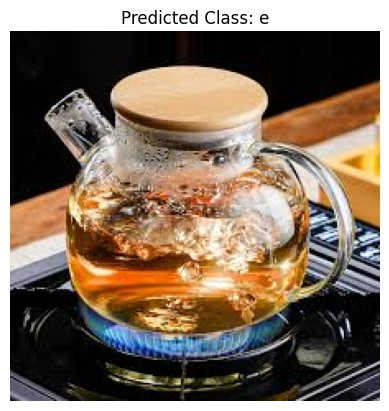

In [ ]:
import torch
import timm  # Import the timm library for model loading
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json
import urllib.request
import os

# Step 1: Download ImageNet Class Index JSON if not available
imagenet_class_index_path = "imagenet_class_index.json"

# Check if ImageNet class index file exists; if not, download it
if not os.path.exists(imagenet_class_index_path):
    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    urllib.request.urlretrieve(url, imagenet_class_index_path)

# Load the ImageNet class index JSON
with open(imagenet_class_index_path) as f:
    imagenet_class_index = json.load(f)

# Step 2: Define the image transformations (resize, normalize, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image to 224x224
    transforms.ToTensor(),          # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

# Step 3: Load an image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Convert to RGB
    image = transform(image)  # Apply transformations
    return image.unsqueeze(0)  # Add batch dimension (1, C, H, W)

# Step 4: Test on your own image
image_path = input("Enter the path to your image: ")  # Let the user input the image path
image_tensor = load_image(image_path)

# Step 5: Move the image tensor to the same device as the model (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

# Step 6: Initialize and move the model to the same device
model = SwinTransformer().to(device)  # Using SwinTransformer
model.eval()  # Set the model to evaluation mode

# Step 7: Make a prediction
with torch.no_grad():  # Disable gradient computation for inference
    output = model(image_tensor)

# Step 8: Process the output (convert logits to probabilities)
probabilities = F.softmax(output, dim=1)

# Step 9: Get the predicted class
predicted_class = torch.argmax(probabilities, dim=1)

# Step 10: Get the class label (e.g., class name) from ImageNet class index
class_label = imagenet_class_index[str(predicted_class.item())]  # Class label

# Step 11: Print the results
print(f"Predicted class index: {predicted_class.item()}")
print(f"Predicted class label: {class_label[1]}")

# Optionally, display top N predicted classes and their probabilities
top_k = 5
probs, indices = torch.topk(probabilities, top_k)
for i in range(top_k):
    class_label = imagenet_class_index[str(indices[0][i].item())][1]
    print(f"Class {indices[0][i].item()} - {class_label} - Probability: {probs[0][i].item():.4f}")

# Step 12: Visualize the image
image = Image.open(image_path)  # Re-load the image to show it with original size
plt.imshow(image)
plt.title(f"Predicted Class: {class_label[1]}")  # Display the predicted class as title
plt.axis('off')  # Turn off axis for clean display
plt.show()


Enter the path to your image: /content/images (2).jpeg
Predicted class index: 954
Predicted class label: banana
Class 954 - banana - Probability: 0.7946
Class 940 - spaghetti_squash - Probability: 0.0038
Class 950 - orange - Probability: 0.0026
Class 951 - lemon - Probability: 0.0024
Class 953 - pineapple - Probability: 0.0021


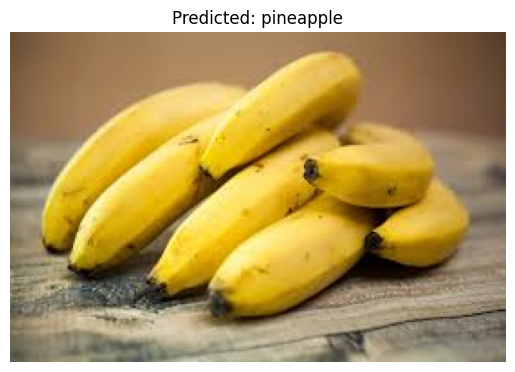

In [ ]:
import torch
import timm  # Import the timm library for model loading
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import os
import json
import urllib.request

# Step 1: Download ImageNet Class Index JSON if not available
imagenet_class_index_path = "imagenet_class_index.json"

# Check if ImageNet class index file exists; if not, download it
if not os.path.exists(imagenet_class_index_path):
    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    urllib.request.urlretrieve(url, imagenet_class_index_path)

# Load the ImageNet class index JSON
with open(imagenet_class_index_path) as f:
    imagenet_class_index = json.load(f)

# Step 2: Define the image transformations (resize, normalize, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image to 224x224
    transforms.ToTensor(),          # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

# Step 3: Load an image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Convert to RGB
    image = transform(image)  # Apply transformations
    return image.unsqueeze(0)  # Add batch dimension (1, C, H, W)

# Step 4: Test on your own image
image_path = input("Enter the path to your image: ")  # Let the user input the image path
image_tensor = load_image(image_path)

# Step 5: Move the image tensor to the same device as the model (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

# Step 6: Initialize and move the model to the same device
model = timm.create_model("swin_base_patch4_window7_224", pretrained=True).to(device)  # Using SwinTransformer
model.eval()  # Set the model to evaluation mode

# Step 7: Make a prediction
with torch.no_grad():  # Disable gradient computation for inference
    output = model(image_tensor)

# Step 8: Process the output (convert logits to probabilities)
probabilities = F.softmax(output, dim=1)

# Step 9: Get the predicted class index
predicted_class = torch.argmax(probabilities, dim=1)

# Step 10: Get the predicted class label (name)
class_label = imagenet_class_index[str(predicted_class.item())][1]

# Step 11: Print the predicted class index and label
print(f"Predicted class index: {predicted_class.item()}")
print(f"Predicted class label: {class_label}")

# Optionally, display top N predicted classes and their probabilities
top_k = 5
probs, indices = torch.topk(probabilities, top_k)
for i in range(top_k):
    class_label = imagenet_class_index[str(indices[0][i].item())][1]
    print(f"Class {indices[0][i].item()} - {class_label} - Probability: {probs[0][i].item():.4f}")

# Step 12: Visualize the image
image = Image.open(image_path)  # Re-load the image to show it with original size
plt.imshow(image)
plt.title(f"Predicted: {class_label}")  # Display the predicted label as title
plt.axis('off')  # Turn off axis for clean display
plt.show()
